# Часть первая. Стандартный A/B тест

## Загружаем данные

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('ab_test_results_aggregated_views_clicks_2.csv')
df.head()

,user_id,group,views,clicks
0,1,control,10.0,0.0
1,2,control,1.0,0.0
2,3,control,1.0,0.0
3,4,control,2.0,0.0
4,5,control,3.0,0.0


## Проверим общую информацию

In [3]:
print(df.info())
print(df.describe())
print(df['group'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  120000 non-null  int64  
 1   group    120000 non-null  object 
 2   views    120000 non-null  float64
 3   clicks   120000 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.7+ MB
None
             user_id          views         clicks
count  120000.000000  120000.000000  120000.000000
mean    60000.500000       4.991075       0.182692
std     34641.160489       5.915200       0.472547
min         1.000000       1.000000       0.000000
25%     30000.750000       2.000000       0.000000
50%     60000.500000       3.000000       0.000000
75%     90000.250000       6.000000       0.000000
max    120000.000000     205.000000       9.000000
group
control    60000
test       60000
Name: count, dtype: int64


## Проверим пропуски и аномалии

In [4]:
print("Пропуски:")
print(df.isnull().sum())

print("Уникальные группы:")
print(df['group'].unique())

Пропуски:
user_id    0
group      0
views      0
clicks     0
dtype: int64
Уникальные группы:
['control' 'test']


## Построим гипотезы

Статистическая постановка гипотезы

$H_0:$ Нет разницы в просмотрах/кликах между группами.

$H_1:$ Есть статистически значимая разница.

Бизнес-гипотеза

$H_0:$ Внедряемое изменение не влияет на вовлечённость пользователей, измеряемую количеством просмотров/кликов. Поведение пользователей в тестовой группе не отличается от контрольной.

$H_1:$ Внедряемое изменение влияет на вовлечённость пользователей и приводит к изменению количества просмотров/кликов по сравнению с контрольной группой.

Односторонняя гипотеза

$H_0:$ Просмотры/переходы в тестовой группе не больше, чем в контрольной.

$H_1:$ Просмотры/переходы в тестовой группе больше, чем в контрольной.

## Метрики

In [5]:
control_views = df[df['group'] == 'control']['views']
test_views = df[df['group'] == 'test']['views']

control_clicks = df[df['group'] == 'control']['clicks']
test_clicks = df[df['group'] == 'test']['clicks']

print(control_views.mean(), control_clicks.mean())
print(test_views.mean(), test_clicks.mean())
print(f"delta views: {(test_views.mean() - control_views.mean())*100}%")
print(f"delta clicks: {(test_clicks.mean() - control_clicks.mean())*100}%")

4.9524 0.17171666666666666
5.02975 0.19366666666666665
delta views: 7.735000000000003%
delta clicks: 2.195%


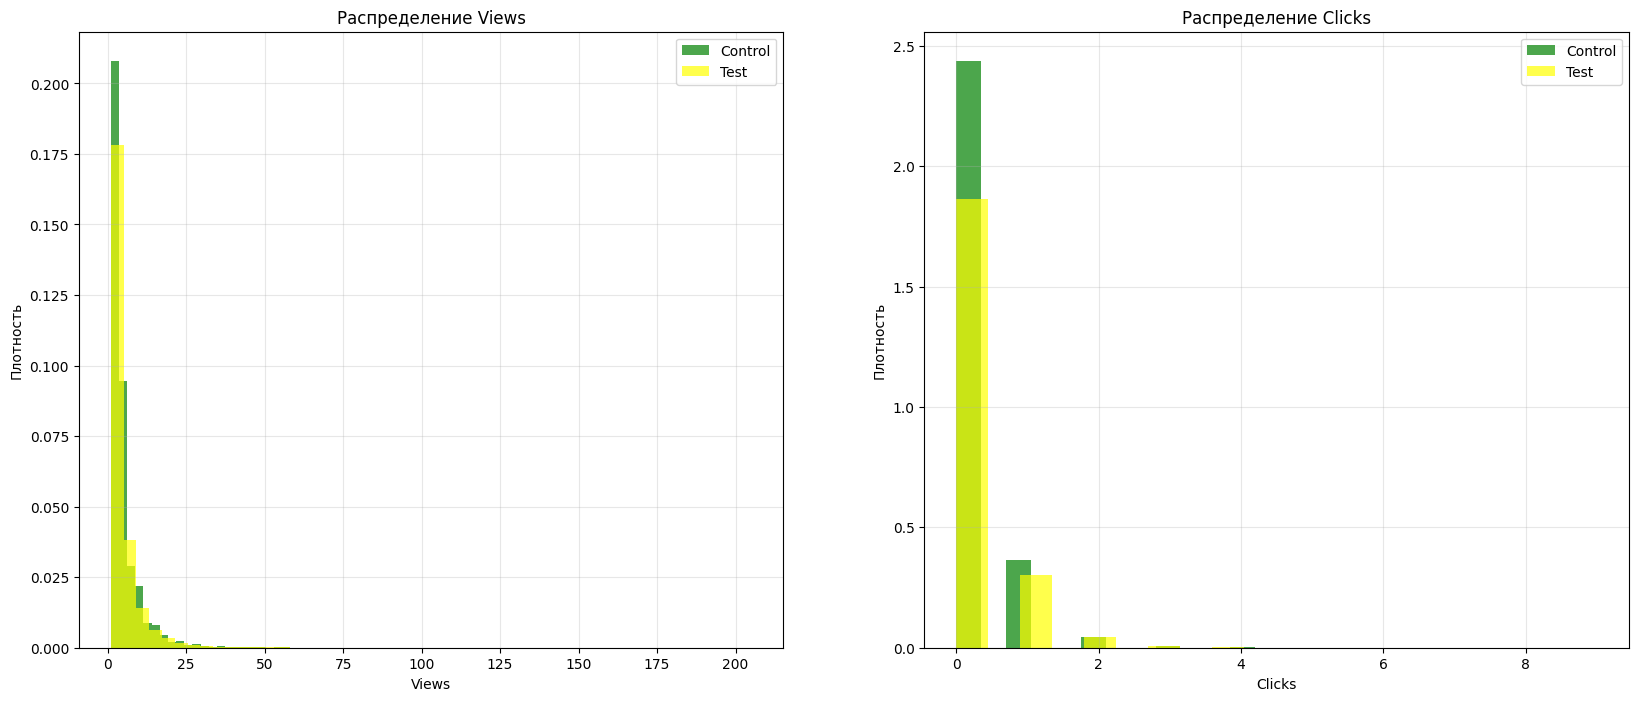

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. Распределение Views
axes[0].hist(control_views, bins=50, alpha=0.7, label='Control', color='green', density=True)
axes[0].hist(test_views, bins=50, alpha=0.7, label='Test', color='yellow', density=True)
axes[0].set_xlabel('Views')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Распределение Views')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Распределение Clicks
axes[1].hist(control_clicks, bins=20, alpha=0.7, label='Control', color='green', density=True)
axes[1].hist(test_clicks, bins=20, alpha=0.7, label='Test', color='yellow', density=True)
axes[1].set_xlabel('Clicks')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Распределение Clicks')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

## Проверка нормальности распределения

Для views - control

In [7]:
from scipy.stats import shapiro

# Проверим нормальность для views в control группе
stat, p = shapiro(control_views)
if p > 0.05:
    print('Распределение нормальное')
else:
    print('Распределение не нормальное')

Распределение не нормальное


Для views - test

In [8]:
stat, p = shapiro(test_views)
if p > 0.05:
    print('Распределение нормальное')
else:
    print('Распределение не нормальное')

Распределение не нормальное


Для clicks - control

In [9]:
stat, p = shapiro(control_clicks)
if p > 0.05:
    print('Распределение нормальное')
else:
    print('Распределение не нормальное')

Распределение не нормальное


Для clicks - test

In [10]:
stat, p = shapiro(test_clicks)
if p > 0.05:
    print('Распределение нормальное')
else:
    print('Распределение не нормальное')

Распределение не нормальное


Эти результаты показывают, что распределение обеих метрик («кликов» и «просмотров») в контрольной и тестовой группах не является нормальным. Это означает, что для анализа данных следует использовать непараметрические методы, так как условия для применения параметрических тестов не выполняются. Для сравнения контрольной и тестовой групп мы будем использовать непараметрический тест - **U-критерий Манна — Уитни.**

PS: К этому же выводу можно прийти, если анализировать ранее построенные графики, заметить ассиметрию

## Статистический тест

Для двусторонней гипотезы

In [11]:
from scipy.stats import mannwhitneyu

p1 = mannwhitneyu(control_views, test_views).pvalue
print("p-value: ",p1)
if p1 < 0.05:
    print('Отвергаем H0')
else:
    print('Не отвергаем H0')

p-value:  0.019769045140100635
Отвергаем H0


In [12]:
p2 = mannwhitneyu(control_clicks, test_clicks).pvalue
print("p-value: ",p2)
if p2 < 0.05:
    print('Отвергаем H0')
else:
    print('Не отвергаем H0')

p-value:  3.362997071095112e-13
Отвергаем H0


Для односторонней альтернативы

In [13]:
p3 = mannwhitneyu(control_clicks, test_clicks, alternative="less").pvalue
print(f"p-value: {p3}")
if p3 < 0.05:
    print('Отвергаем H0')
else:
    print('Не отвергаем H0')

p-value: 1.681498535547556e-13
Отвергаем H0


In [14]:
p4 = mannwhitneyu(control_views, test_views, alternative="less").pvalue
print(f"p-value: {p4}")
if p4 < 0.05:
    print('Отвергаем H0')
else:
    print('Не отвергаем H0')

p-value: 0.009884522570050317
Отвергаем H0


Для views на уровне значимости 0.05 p-value одностороннего теста Манна–Уитни составило 0.00988 и 0.0197 для двустороннего, что позволяет отвергнуть нулевую гипотезу в обоих случаях. Аналогично для clicks.

Для всех рассматриваемых метрик различия между тестовой и контрольной группами статистически значимы как при двусторонней, так и при односторонней проверке гипотез. Это указывает не только на наличие различий, но и на их направленность - значения метрик в тестовой группе статистически значимо выше.

## Найдем размер эффекта.

In [15]:
pip install cliffs-delta

In [16]:
from cliffs_delta import cliffs_delta

delta_views, res1 = cliffs_delta(control_views, test_views)

print(delta_views,res1)

-0.007687463611111111 negligible


In [17]:
delta_clicks, res2 = cliffs_delta(control_clicks, test_clicks)

print(delta_clicks,res2)

-0.01521000111111111 negligible


Или вручную

In [18]:
import bisect

def cliffs_delta(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    n1 = len(a)
    n2 = len(b)

    b_sorted = np.sort(b)

    greater = 0
    less = 0

    for x in a:
        less += bisect.bisect_left(b_sorted, x)
        greater += (n2 - bisect.bisect_right(b_sorted, x))

    delta = (greater - less) / (n1 * n2)
    return delta


In [19]:
delta_views = cliffs_delta(control_views, test_views)
print(delta_views)

0.007687463611111111


In [20]:
delta_clicks = cliffs_delta(control_clicks, test_clicks)
print(delta_clicks)

0.01521000111111111


# Часть вторая. Углубленный A/B тест

## 1. А/A тест

**Нулевая гипотеза (H₀)**
При случайном разбиении контрольной группы на две подгруппы, распределение метрик (просмотров и кликов) в этих подгруппах не различается. 

**Альтернативная гипотеза (H₁)**
При случайном разбиении контрольной группы на две подгруппы, распределение метрик в этих подгруппах различается статистически значимо.

## Проверка гипотезы

AA-test iterations: 100%|██████████████████████████████████████████████████████████| 1000/1000 [00:13<00:00, 76.12it/s]


РЕЗУЛЬТАТЫ AA-TECTA (100 итераций)
Ошибка I рода для views:  4.60% (должно быть ~5%)
Ошибка I рода для clicks: 4.80% (должно быть ~5%)



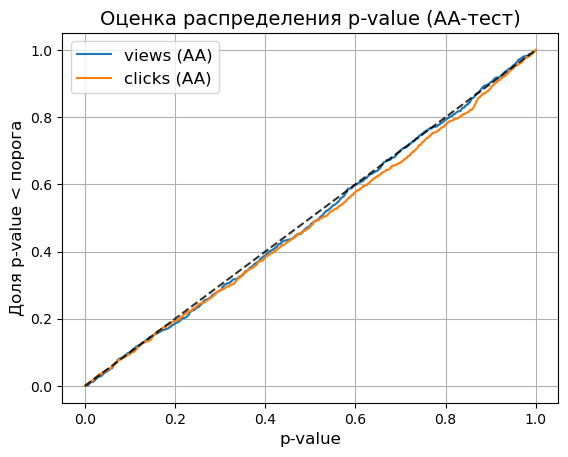

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mannwhitneyu
from tqdm import tqdm

def plot_pvalue_distribution(dict_pvalues):
    """Рисует графики распределения p-value."""
    X = np.linspace(0, 1, 1000)
    for name, pvalues in dict_pvalues.items():
        Y = [np.mean(pvalues < x) for x in X]
        plt.plot(X, Y, label=name)
    
    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)
    plt.title('Оценка распределения p-value (AA-тест)', size=14)
    plt.xlabel('p-value', size=12)
    plt.ylabel('Доля p-value < порога', size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

# Выделяем контрольную группу
control_df = df[df['group'] == 'control'].copy()
control_users = control_df['user_id'].unique()

# Хранилище p-value
pvalues_views = []
pvalues_clicks = []

# 1000 итераций AA-теста
n_iterations = 1000

for seed in tqdm(range(n_iterations), desc="AA-test iterations"):
    # Случайное разбиение контрольной группы на две подгруппы
    np.random.seed(seed)
    shuffled_users = np.random.permutation(control_users)
    split_point = len(control_users) // 2
    group1_users = shuffled_users[:split_point]
    group2_users = shuffled_users[split_point:]
    
    group1 = control_df[control_df['user_id'].isin(group1_users)]
    group2 = control_df[control_df['user_id'].isin(group2_users)]
    
    # Mann-Whitney U test для views
    _, p_views = mannwhitneyu(group1['views'], group2['views'])
    pvalues_views.append(p_views)
    
    # Mann-Whitney U test для clicks
    _, p_clicks = mannwhitneyu(group1['clicks'], group2['clicks'])
    pvalues_clicks.append(p_clicks)

# Оценка ошибки I рода
alpha = 0.05
error_rate_views = np.mean(np.array(pvalues_views) < alpha)
error_rate_clicks = np.mean(np.array(pvalues_clicks) < alpha)

print(f"РЕЗУЛЬТАТЫ AA-TECTA (1000 итераций)")
print(f"Ошибка I рода для views:  {error_rate_views:.2%} (должно быть ~5%)")
print(f"Ошибка I рода для clicks: {error_rate_clicks:.2%} (должно быть ~5%)")
print()

# Графики
plot_pvalue_distribution({
    'views (AA)': pvalues_views,
    'clicks (AA)': pvalues_clicks
})

Таким образом, для просмотров и кликов p > 0.05, поэтому у нас нет оснований отвергнуть нулевую гипотезу:
- Распределение просмотров и кликов в двух случайных подгруппах контрольной группы статистически не различается


## 2. Ratio-метрики. CTR

### Создаем CTR

Пользователей с views=0: 0
CTR статистика:
count    120000.000000
mean          0.036651
std           0.117812
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: ctr_user, dtype: float64


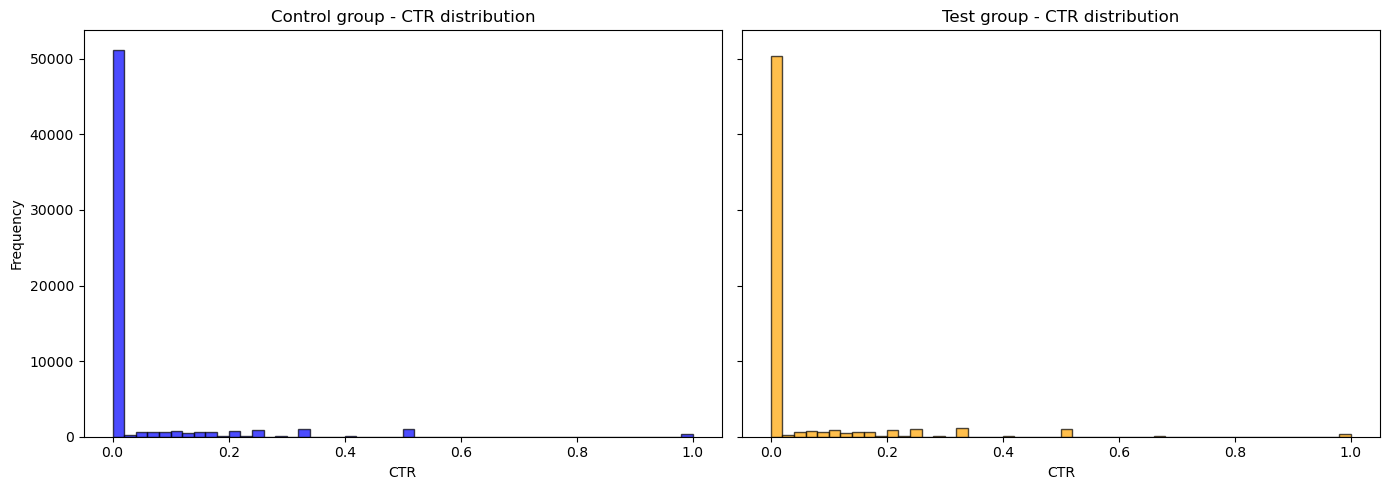

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Создаем CTR, обрабатывая деление на ноль
df['ctr_user'] = df['clicks'] / df['views']
df.loc[df['views'] == 0, 'ctr'] = 0

# Проверяем
print(f"Пользователей с views=0: {(df['views'] == 0).sum()}")
print(f"CTR статистика:\n{df['ctr_user'].describe()}")

# Разделяем по группам
control_ctr = df[df['group'] == 'control']['ctr_user'].dropna()
test_ctr = df[df['group'] == 'test']['ctr_user'].dropna()

# Рисуем гистограммы рядом
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(control_ctr, bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0].set_title('Control group - CTR distribution')
axes[0].set_xlabel('CTR')
axes[0].set_ylabel('Frequency')

axes[1].hist(test_ctr, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Test group - CTR distribution')
axes[1].set_xlabel('CTR')

plt.tight_layout()
plt.show()

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, poisson, binom, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

Функции для генерации синтетических данных

In [15]:
def generate_count_data(n_users, lambda_rate):
    """
    Генерация count-данных (views, clicks)
    из распределения Пуассона
    
    n_users: количество пользователей
    lambda_rate: среднее значение (параметр Пуассона)
    """
    return np.random.poisson(lambda_rate, n_users)


def generate_ctr_data(n_views, p_ctr):
    """
    Генерация CTR-данных (число кликов при фиксированных просмотрах)
    из биномиального распределения
    
    n_views: количество просмотров
    p_ctr: вероятность клика
    """
    return np.random.binomial(n_views, p_ctr)

Функция для одной итерации синтетического AA-теста

In [16]:
def run_synthetic_aa_test(metric_type, n_users, params, alpha=0.05):
    """
    Одна итерация синтетического AA-теста
    
    metric_type: 'views', 'clicks', 'ctr'
    n_users: размер выборки
    params: параметры распределения
    alpha: уровень значимости
    
    Возвращает:
    - rejected: отвергнута ли H0 (1 - ошибка I рода, 0 - нет)
    - p_value: значение p-value
    """
    
    if metric_type in ['views', 'clicks']:
        # Для count-метрик
        lambda_rate = params['lambda_rate']
        
        # Генерируем две независимые выборки (без эффекта)
        control = generate_count_data(n_users, lambda_rate)
        test = generate_count_data(n_users, lambda_rate)
        
        # Непараметрический тест Манна-Уитни (данные ненормальные)
        _, p_value = mannwhitneyu(control, test, alternative='two-sided')
        
    elif metric_type == 'ctr':
        # Для CTR: сначала генерируем просмотры, потом клики
        p_ctr = params['p_ctr']
        min_views = params.get('min_views', 1)
        max_views = params.get('max_views', 10)
        
        # Генерируем число просмотров для каждого пользователя
        control_views = np.random.randint(min_views, max_views + 1, n_users)
        test_views = np.random.randint(min_views, max_views + 1, n_users)
        
        # Генерируем число кликов (биномиальное распределение)
        control_clicks = generate_ctr_data(control_views, p_ctr)
        test_clicks = generate_ctr_data(test_views, p_ctr)
        
        # Тест пропорций для ratio-метрики
        _, p_value = proportions_ztest(
            [control_clicks.sum(), test_clicks.sum()],
            [control_views.sum(), test_views.sum()]
        )
    
    else:
        raise ValueError(f"Unknown metric_type: {metric_type}")
    
    rejected = 1 if p_value < alpha else 0
    
    return rejected, p_value

In [17]:
def run_synthetic_aa_simulation(metric_type, n_users, params, n_iterations=10000):
    """
    Массовый прогон синтетического AA-теста
    
    Возвращает:
    - error_rate: точечная оценка ошибки I рода
    - ci_lower, ci_upper: 95% доверительный интервал
    - p_values: массив всех p-value
    """
    
    rejected_list = []
    p_values = []
    
    for _ in tqdm(range(n_iterations), desc=f"AA-test: {metric_type}"):
        rejected, p_value = run_synthetic_aa_test(metric_type, n_users, params)
        rejected_list.append(rejected)
        p_values.append(p_value)
    
    error_rate = np.mean(rejected_list)
    
    # Доверительный интервал для ошибки I рода (нормальная аппроксимация)
    z = norm.ppf(0.975)  # 1.96 для 95% CI
    se = np.sqrt(error_rate * (1 - error_rate) / n_iterations)
    ci_lower = error_rate - z * se
    ci_upper = error_rate + z * se
    
    return {
        'error_rate': error_rate,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'p_values': p_values,
        'rejected_count': sum(rejected_list)
    }

In [18]:
def plot_pvalue_distribution(p_values, metric_name):
    """
    Гистограмма распределения p-value
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Гистограмма
    axes[0].hist(p_values, bins=50, edgecolor='black', alpha=0.7, density=True)
    axes[0].axhline(y=1, xmin=0, xmax=1, color='red', linestyle='--', 
                    label='Равномерное распределение (y=1)')
    axes[0].set_xlabel('p-value')
    axes[0].set_ylabel('Плотность')
    axes[0].set_title(f'{metric_name}: Распределение p-value')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Q-Q plot против равномерного распределения
    uniform_quantiles = np.linspace(0, 1, len(p_values))
    sorted_p = np.sort(p_values)
    
    axes[1].plot(uniform_quantiles, sorted_p, 'bo', alpha=0.5, markersize=2)
    axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Равномерное распределение')
    axes[1].set_xlabel('Теоретические квантили (Uniform)')
    axes[1].set_ylabel('Эмпирические квантили p-value')
    axes[1].set_title(f'{metric_name}: Q-Q plot')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_error_rate_with_ci(error_rate, ci_lower, ci_upper, metric_name, alpha=0.05):
    """
    График ошибки I рода с доверительным интервалом
    """
    plt.figure(figsize=(8, 6))
    
    plt.bar(metric_name, error_rate, color='steelblue', alpha=0.7, 
            label=f'Ошибка I рода = {error_rate:.3f}')
    plt.errorbar(metric_name, error_rate, 
                 yerr=[[error_rate - ci_lower], [ci_upper - error_rate]],
                 fmt='none', color='black', capsize=10, 
                 label=f'95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]')
    plt.axhline(y=alpha, color='red', linestyle='--', 
                label=f'Теоретический уровень α = {alpha}')
    
    plt.ylabel('Ошибка I рода')
    plt.title(f'{metric_name}: Ошибка I рода с доверительным интервалом')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [19]:
# Параметры, полученные (из предыдущего анализа df)

# Для views: среднее = 4.99
LAMBDA_VIEWS = 4.99

# Для clicks: среднее = 0.18
LAMBDA_CLICKS = 0.18

# Для CTR: p = 0.034673 (CTR в контрольной группе)
P_CTR = 0.034673

# Размер выборки 
N_USERS = 60000  # по 60000 на группу

# Количество итераций
N_ITERATIONS = 10000

In [21]:
print()
print("СИНТЕТИЧЕСКИЙ AA-TECT")
print()

# 1. Для метрики views
print("1. Запуск для метрики VIEWS")
result_views = run_synthetic_aa_simulation(
    metric_type='views',
    n_users=N_USERS,
    params={'lambda_rate': LAMBDA_VIEWS},
    n_iterations=N_ITERATIONS
)

# 2. Для метрики clicks
print("\n2. Запуск для метрики CLICKS")
result_clicks = run_synthetic_aa_simulation(
    metric_type='clicks',
    n_users=N_USERS,
    params={'lambda_rate': LAMBDA_CLICKS},
    n_iterations=N_ITERATIONS
)

# 3. Для метрики CTR
print("\n3. Запуск для метрики CTR")
result_ctr = run_synthetic_aa_simulation(
    metric_type='ctr',
    n_users=N_USERS,
    params={
        'p_ctr': P_CTR,
        'min_views': 1,
        'max_views': 20
    },
    n_iterations=N_ITERATIONS
)


СИНТЕТИЧЕСКИЙ AA-TECT

1. Запуск для метрики VIEWS


AA-test: views: 100%|████████████████████████████████████████████████████████████| 10000/10000 [03:05<00:00, 53.85it/s]



2. Запуск для метрики CLICKS


AA-test: clicks: 100%|██████████████████████████████████████████████████████████| 10000/10000 [01:36<00:00, 103.91it/s]



3. Запуск для метрики CTR


AA-test: ctr: 100%|█████████████████████████████████████████████████████████████| 10000/10000 [01:19<00:00, 125.28it/s]


In [23]:
print("\n")
print("РЕЗУЛЬТАТЫ СИНТЕТИЧЕСКОГО AA-TECTA")
print()

print(f"{'Метрика':<10} {'Ошибка I рода':<15} {'95% CI':<25}")
print("-" * 65)

for name, result in [('views', result_views), ('clicks', result_clicks), ('CTR', result_ctr)]:
    ci_str = f"[{result['ci_lower']:.3f}, {result['ci_upper']:.3f}]"
    print(f"{name:<10} {result['error_rate']:.4f}        {ci_str:<25}")



РЕЗУЛЬТАТЫ СИНТЕТИЧЕСКОГО AA-TECTA

Метрика    Ошибка I рода   95% CI                   
-----------------------------------------------------------------
views      0.0505        [0.046, 0.055]           
clicks     0.0528        [0.048, 0.057]           
CTR        0.0494        [0.045, 0.054]           


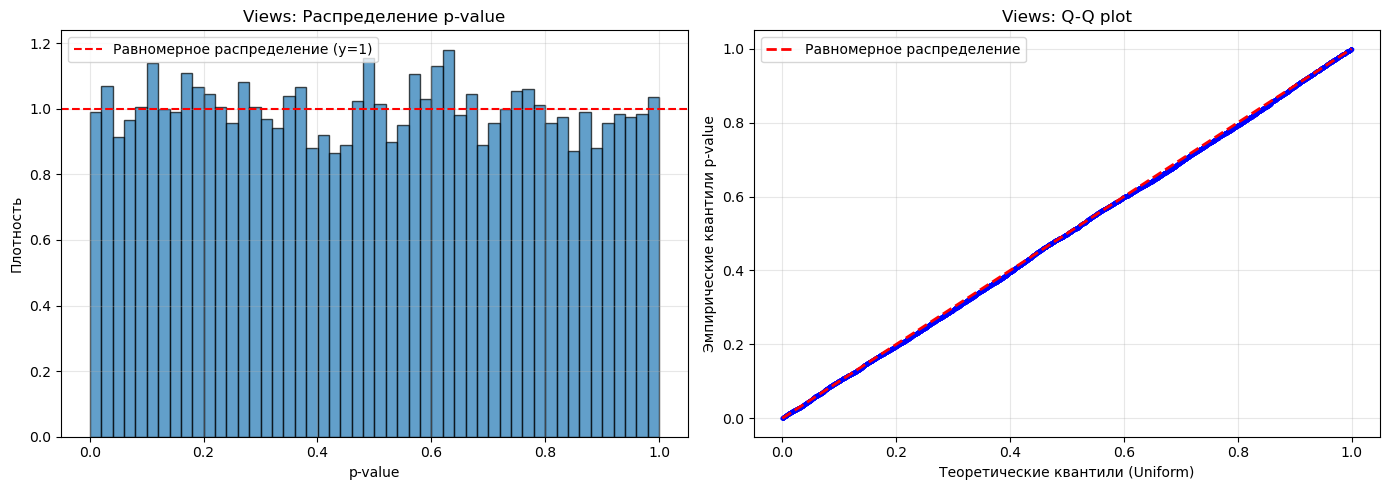

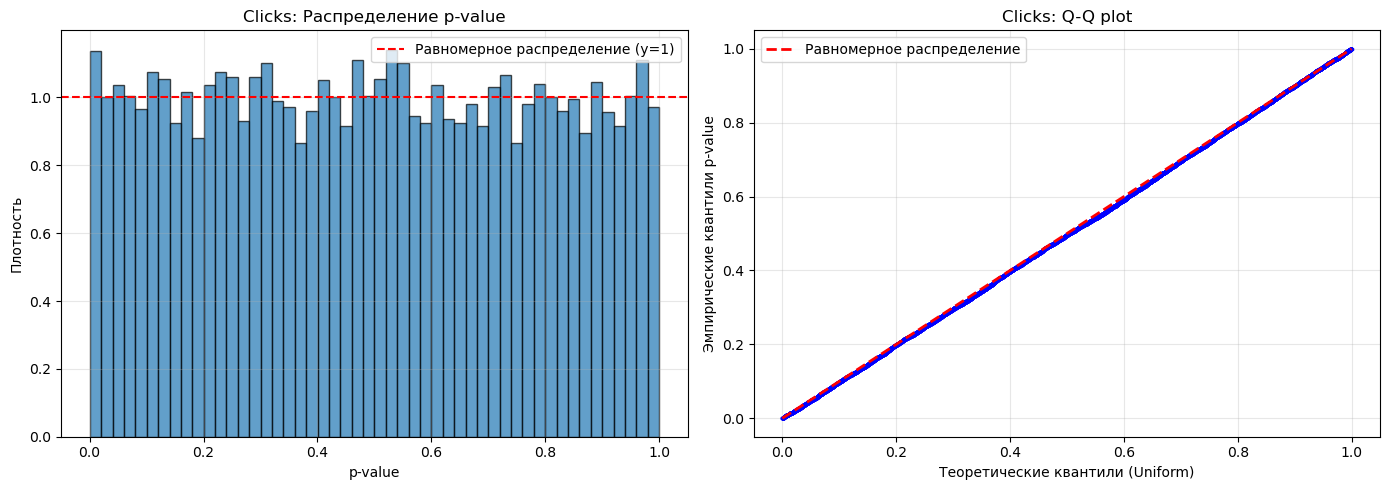

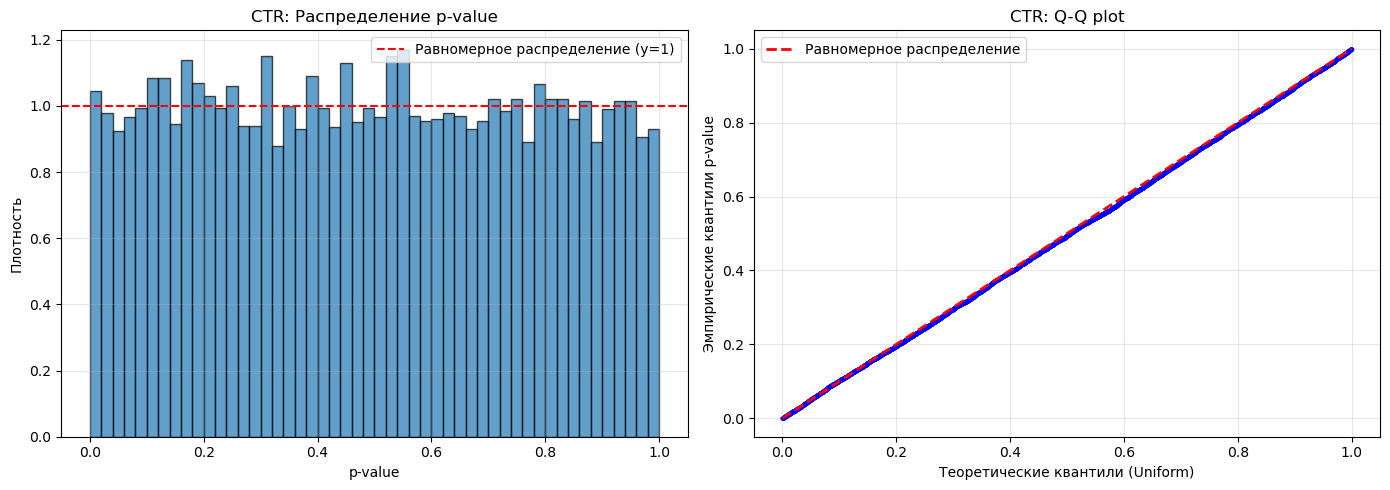

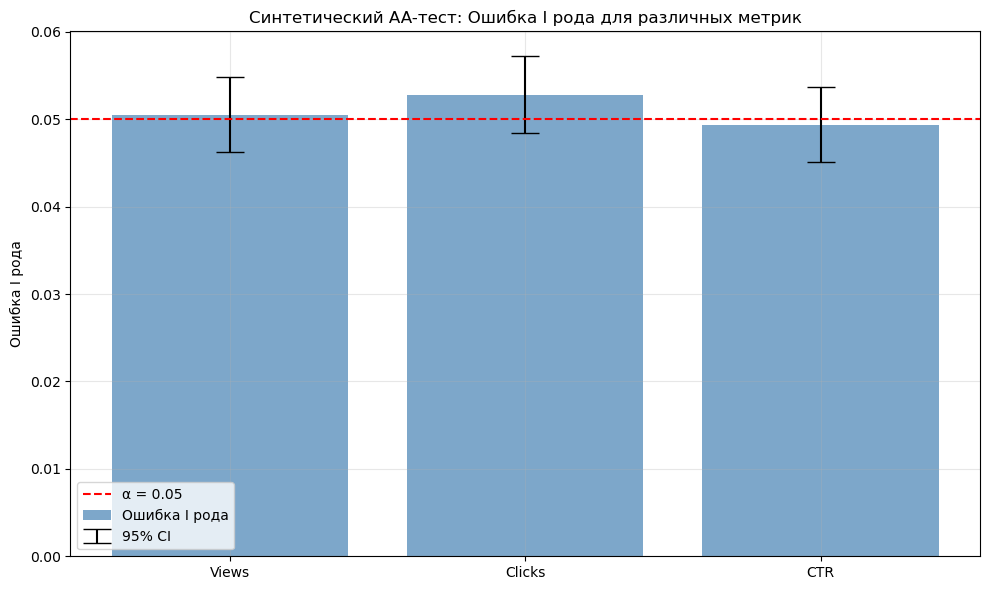

In [27]:
# Распределения p-value
plot_pvalue_distribution(result_views['p_values'], 'Views')
plot_pvalue_distribution(result_clicks['p_values'], 'Clicks')
plot_pvalue_distribution(result_ctr['p_values'], 'CTR')

# Ошибка I рода с доверительными интервалами
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Views', 'Clicks', 'CTR']
error_rates = [result_views['error_rate'], result_clicks['error_rate'], result_ctr['error_rate']]
ci_lowers = [result_views['ci_lower'], result_clicks['ci_lower'], result_ctr['ci_lower']]
ci_uppers = [result_views['ci_upper'], result_clicks['ci_upper'], result_ctr['ci_upper']]

x = np.arange(len(metrics))
ax.bar(x, error_rates, color='steelblue', alpha=0.7, label='Ошибка I рода')
ax.errorbar(x, error_rates, 
            yerr=[[error_rates[i] - ci_lowers[i] for i in range(len(metrics))],
                  [ci_uppers[i] - error_rates[i] for i in range(len(metrics))]],
            fmt='none', color='black', capsize=10, label='95% CI')
ax.axhline(y=0.05, color='red', linestyle='--', label='α = 0.05')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Ошибка I рода')
ax.set_title('Синтетический AA-тест: Ошибка I рода для различных метрик')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Линеаризация

In [27]:
def safe_divide(x, y):
    return x / y if y != 0 else np.nan

def linearization_type_1_real(control, test):

    # Числитель = clicks, знаменатель = views
    x_num = test['clicks'].values      # X^t
    x_denom = test['views'].values     # Y^t
    y_num = control['clicks'].values   # X^c
    y_denom = control['views'].values  # Y^c
    
    # R^c = CTR в контроле
    r_control = y_num.sum() / y_denom.sum()
    
    # Линеаризованные метрики
    control_linear = y_num - r_control * y_denom
    test_linear = x_num - r_control * x_denom
    
    # t-test (Welch)
    t_stat, p_value = stats.ttest_ind(control_linear, test_linear, equal_var=False)
    
    # Разница между группами
    control_mean = control_linear.mean()
    test_mean = test_linear.mean()
    
    return {
        'r_control': r_control,
        'control_linear_mean': control_mean,
        'test_linear_mean': test_mean,
        'diff': test_mean - control_mean,
        't_stat': t_stat,
        'p_value': p_value,
        'is_significant': p_value < 0.05
    }

In [29]:
# Подготовка данных
control = df[df['group'] == 'control'][['clicks', 'views']]
test = df[df['group'] == 'test'][['clicks', 'views']]

# Линеаризация Тип 1
result_t1 = linearization_type_1_real(control, test)

print("Линеаризация")
print(f"R^c (CTR_control): {result_t1['r_control']:.6f}")
print(f"L_control_mean: {result_t1['control_linear_mean']:.6f}")
print(f"L_test_mean:    {result_t1['test_linear_mean']:.6f}")
print(f"Разница:        {result_t1['diff']:.6f}")
print(f"t-statistic:    {result_t1['t_stat']:.4f}")
print(f"p-value:        {result_t1['p_value']:.6f}")
print(f"Значимо:        {result_t1['is_significant']}")

Линеаризация
R^c (CTR_control): 0.034673
L_control_mean: -0.000000
L_test_mean:    0.019268
Разница:        0.019268
t-statistic:    -7.9001
p-value:        0.000000
Значимо:        True


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, probplot

def check_normality_with_plots(data, title):
    """
    Проверка нормальности с графиками
    """
    # Очистка от NaN
    data_clean = data.dropna()
    
    stat, p_value = shapiro(data_clean)
    
    # Создание графиков
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    
    # 1. Гистограмма
    axes[0].hist(data_clean, bins=50, edgecolor='black', alpha=0.7, density=True)
    sns.kdeplot(data_clean, ax=axes[0], color='red', linewidth=2)
    axes[0].set_title(f'{title}\nГистограмма + KDE')
    axes[0].set_xlabel('Значение')
    axes[0].set_ylabel('Плотность')
    
    # 2. Q-Q plot
    probplot(data_clean, dist="norm", plot=axes[1])
    axes[1].set_title(f'{title}\nQ-Q plot')
    axes[1].get_lines()[0].set_color('blue')
    axes[1].get_lines()[1].set_color('red')
    
    # Результат теста
    is_normal = p_value > 0.05
    result_text = "Нормальное" if is_normal else "Отличается от нормального"
    
    print(f"{title}:")
    print(f"  Shapiro-Wilk p-value: {p_value:.6f}")
    print(f"  Вывод: распределение {result_text}")
    print(f"  Можем использовать t-test" if is_normal else "Нужен непараметрический тест")
    print()
    
    return p_value, is_normal

Линеаризованная метрика (Control):
  Shapiro-Wilk p-value: 0.000000
  Вывод: распределение Отличается от нормального
Нужен непараметрический тест

Линеаризованная метрика (Test):
  Shapiro-Wilk p-value: 0.000000
  Вывод: распределение Отличается от нормального
Нужен непараметрический тест



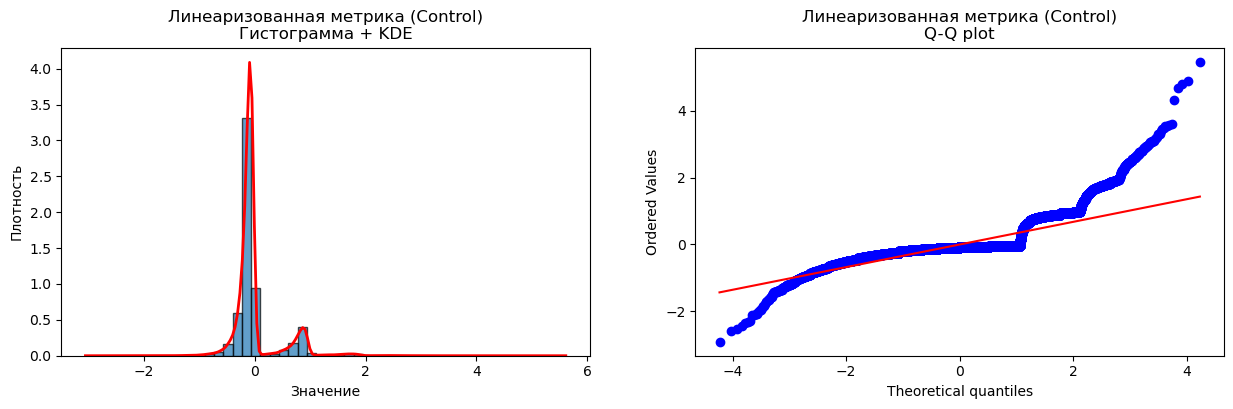

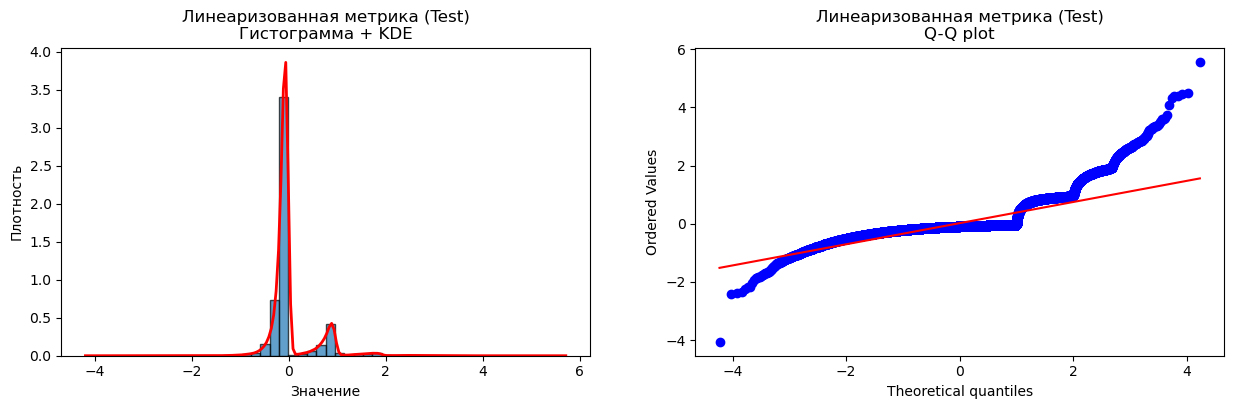

In [37]:
# Параметры
control = df[df['group'] == 'control'][['clicks', 'views']]
test = df[df['group'] == 'test'][['clicks', 'views']]

# R^c = CTR в контроле
r_control = control['clicks'].sum() / control['views'].sum()

# Линеаризация
control_linear = control['clicks'].values - r_control * control['views'].values
test_linear = test['clicks'].values - r_control * test['views'].values

df_linear = pd.DataFrame({
    'control_linear': control_linear,
    'test_linear': test_linear
})

# Проверка нормальности для контрольной группы
p_c, is_normal_c = check_normality_with_plots(df_linear['control_linear'], 'Линеаризованная метрика (Control)')

# Проверка нормальности для тестовой группы
p_t, is_normal_t = check_normality_with_plots(df_linear['test_linear'], 'Линеаризованная метрика (Test)')

Непараметрический тест к данным после линеаризации?

In [39]:
def linearization_type_2_real(control, test):
    """
    Тип 2: Разложение в ряд Тейлора
    """
    # Данные тестовой группы
    x_num = test['clicks'].values
    x_denom = test['views'].values
    
    # Данные контрольной группы
    y_num = control['clicks'].values
    y_denom = control['views'].values
    
    # Средние
    x_num_bar = np.mean(x_num)
    y_num_bar = np.mean(y_num)
    x_denom_bar = np.mean(x_denom)
    y_denom_bar = np.mean(y_denom)
    
    # CTR в группах
    x_estimator = safe_divide(x_num_bar, x_denom_bar)
    y_estimator = safe_divide(y_num_bar, y_denom_bar)
    
    # Линеаризация Тип 2 (ряд Тейлора)
    x_linear = x_estimator + (1 / x_denom_bar) * (x_num - x_estimator * x_denom)
    y_linear = y_estimator + (1 / y_denom_bar) * (y_num - y_estimator * y_denom)
    
    # Проверка нормальности после линеаризации
    _, p_norm_x = shapiro(x_linear)
    _, p_norm_y = shapiro(y_linear)
    
    print(f"Нормальность после Тип 2 (test):  p={p_norm_x:.6f} ")
    print(f"Нормальность после Тип 2 (control): p={p_norm_y:.6f}")
    
    # t-test
    t_stat, p_value = stats.ttest_ind(x_linear, y_linear, equal_var=False)
    
    return {
        'x_estimator': x_estimator,
        'y_estimator': y_estimator,
        'p_norm_test': p_norm_x,
        'p_norm_control': p_norm_y,
        't_stat': t_stat,
        'p_value': p_value,
        'is_significant': p_value < 0.05
    }

In [42]:
control = df[df['group'] == 'control'][['clicks', 'views']]
test = df[df['group'] == 'test'][['clicks', 'views']]

result_t2 = linearization_type_2_real(control, test)

print("\nЛинеаризация Тип 2 (ряд Тейлора)")
print(f"CTR_control (оценка): {result_t2['y_estimator']:.6f}")
print(f"CTR_test (оценка):    {result_t2['x_estimator']:.6f}")
print(f"t-statistic: {result_t2['t_stat']:.4f}")
print(f"p-value:     {result_t2['p_value']:.6f}")
print(f"Значимо:     {result_t2['is_significant']}")

Нормальность после Тип 2 (test):  p=0.000000 
Нормальность после Тип 2 (control): p=0.000000

Линеаризация Тип 2 (ряд Тейлора)
CTR_control (оценка): 0.034673
CTR_test (оценка):    0.038504
t-statistic: 7.8441
p-value:     0.000000
Значимо:     True


CTR_control: 0.034673
CTR_test:    0.038504

ЛИНЕАРИЗАЦИЯ ТИП 2 


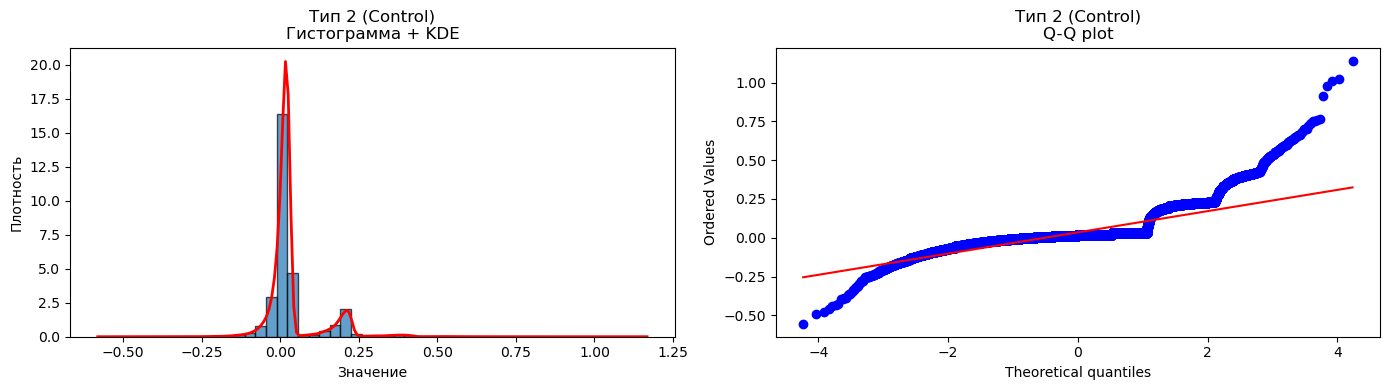

Тип 2 (Control): Shapiro-Wilk p-value = 0.000000 Отличается от нормального



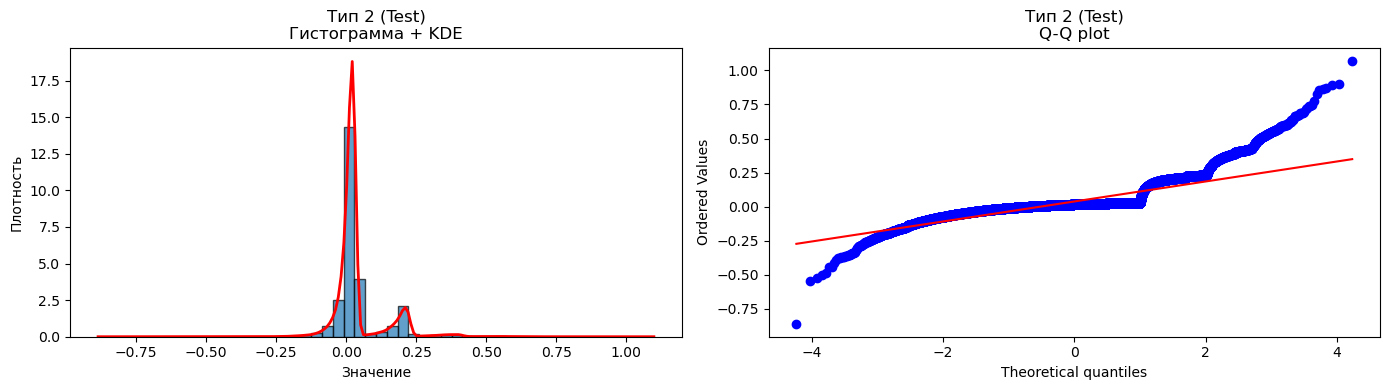

Тип 2 (Test): Shapiro-Wilk p-value = 0.000000 Отличается от нормального



In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import shapiro, probplot, ttest_ind

def check_normality_with_plots(data, title):
    """Проверка нормальности с графиками"""
    data_clean = data.dropna()
    
    stat, p_value = shapiro(data_clean)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Гистограмма
    axes[0].hist(data_clean, bins=50, edgecolor='black', alpha=0.7, density=True)
    sns.kdeplot(data_clean, ax=axes[0], color='red', linewidth=2)
    axes[0].set_title(f'{title}\nГистограмма + KDE')
    axes[0].set_xlabel('Значение')
    axes[0].set_ylabel('Плотность')
    
    # Q-Q plot
    probplot(data_clean, dist="norm", plot=axes[1])
    axes[1].set_title(f'{title}\nQ-Q plot')
    axes[1].get_lines()[0].set_color('blue')
    axes[1].get_lines()[1].set_color('red')
    
    plt.tight_layout()
    plt.show()
    
    is_normal = p_value > 0.05
    print(f"{title}: Shapiro-Wilk p-value = {p_value:.6f} {'Нормальное' if is_normal else 'Отличается от нормального'}")
    print()
    
    return p_value, is_normal


def safe_divide(x, y):
    return x / y if y != 0 else np.nan


# Данные
control = df[df['group'] == 'control'][['clicks', 'views']]
test = df[df['group'] == 'test'][['clicks', 'views']]

# Средние по группам
x_num_bar = test['clicks'].mean()
x_denom_bar = test['views'].mean()
y_num_bar = control['clicks'].mean()
y_denom_bar = control['views'].mean()

# CTR в группах
ctr_test = safe_divide(x_num_bar, x_denom_bar)
ctr_control = safe_divide(y_num_bar, y_denom_bar)

print(f"CTR_control: {ctr_control:.6f}")
print(f"CTR_test:    {ctr_test:.6f}")
print()

# Линеаризация Тип 2 (ряд Тейлора)
control_linear_type2 = ctr_control + (1 / y_denom_bar) * (control['clicks'] - ctr_control * control['views'])
test_linear_type2 = ctr_test + (1 / x_denom_bar) * (test['clicks'] - ctr_test * test['views'])

# Проверка нормальности
print("ЛИНЕАРИЗАЦИЯ ТИП 2 ")
p_c2, norm_c2 = check_normality_with_plots(control_linear_type2, 'Тип 2 (Control)')
p_t2, norm_t2 = check_normality_with_plots(test_linear_type2, 'Тип 2 (Test)')


### Z-тест

In [12]:
from statsmodels.stats.proportion import proportions_ztest

# Данные
clicks_control = df[df['group'] == 'control']['clicks'].sum()
views_control = df[df['group'] == 'control']['views'].sum()
clicks_test = df[df['group'] == 'test']['clicks'].sum()
views_test = df[df['group'] == 'test']['views'].sum()

# Односторонний тест (test > control)
stat, p_value = proportions_ztest(
    [clicks_test, clicks_control],
    [views_test, views_control],
    alternative='larger'  # проверяем, что test > control
)

print(f"CTR_control: {clicks_control/views_control:.6f}")
print(f"CTR_test: {clicks_test/views_test:.6f}")
print(f"p-value (односторонний): {p_value:.6f}")

CTR_control: 0.034673
CTR_test: 0.038504
p-value (односторонний): 0.000000


CTR в тесте статистически значимо выше

### Дельта-метод

In [13]:
import numpy as np
from scipy import stats

def check_delta_method_for_ctr(control, test):
    """
    Дельта-метод для CTR = sum(clicks) / sum(views)

    Возвращает p-value (двусторонний)
    """
    
    def get_metrics_and_var(data):
        clicks = data['clicks'].values
        views = data['views'].values
        
        n_users = len(data)
        
        # Средние
        mean_views = np.mean(views)
        mean_clicks = np.mean(clicks)
        
        # Дисперсии и ковариация
        var_views = np.var(views, ddof=0)
        var_clicks = np.var(clicks, ddof=0)
        cov = np.cov(views, clicks, ddof=0)[0, 1]
        
        # Общий CTR = sum(clicks) / sum(views)
        total_ctr = np.sum(clicks) / np.sum(views)
        
        # Дельта-метод: дисперсия ratio-метрики
        var_ratio = (
            var_clicks / (mean_views ** 2) -
            2 * (mean_clicks / (mean_views ** 3)) * cov +
            (mean_clicks ** 2 / (mean_views ** 4)) * var_views
        ) / n_users
        
        return total_ctr, var_ratio
    
    # Получаем для контрольной и тестовой групп
    ctr_control, var_control = get_metrics_and_var(control)
    ctr_test, var_test = get_metrics_and_var(test)
    
    # Разница метрик
    delta = ctr_test - ctr_control
    
    # Дисперсия разницы (сумма дисперсий, т.к. группы независимы)
    var_delta = var_control + var_test
    
    # z-статистика
    z = delta / np.sqrt(var_delta)
    
    # Двусторонний p-value
    p_value = (1 - stats.norm.cdf(np.abs(z))) * 2
    
    return {
        'ctr_control': ctr_control,
        'ctr_test': ctr_test,
        'delta': delta,
        'var_delta': var_delta,
        'z': z,
        'p_value': p_value
    }

In [14]:
# Разделяем данные
control = df[df['group'] == 'control'][['clicks', 'views']]
test = df[df['group'] == 'test'][['clicks', 'views']]

# Запускаем дельта-метод
result = check_delta_method_for_ctr(control, test)

print("Дельта-метод для CTR")
print(f"CTR_control: {result['ctr_control']:.6f}")
print(f"CTR_test:    {result['ctr_test']:.6f}")
print(f"Разница:     {result['delta']:.6f}")
print(f"z-statistic: {result['z']:.4f}")
print(f"p-value:     {result['p_value']:.6f}")

if result['p_value'] < 0.05:
    print("Разница статистически значима")
else:
    print("Разница не значима")

Дельта-метод для CTR
CTR_control: 0.034673
CTR_test:    0.038504
Разница:     0.003831
z-statistic: 7.8442
p-value:     0.000000
Разница статистически значима


При многократном аа тесте нет равномерного распределение - побакетная агрегация. 

Cuped не применим. 1 юзер только в одной группе